# 학습내용

1. GGUF 모델 변환의 필요성
2. GGUF 모델 성능 테스트
3. GUFF 모델 변환 하기
4. Benchmark Tool로 성능 테스트
5. GGUF 포맷의 한계점
6. GGUF 모델 허깅페이스에 배포하기

# 1. GGUF 모델 변환의 필요성
- 모델 변환을 왜 해야하는지에 대해서 이해해 봅시다.

### llama.cpp 라이브러리 소개

- 모델변환이 왜 필요한지 살펴보기 전, llama.cpp 라이브러리부터 알아봅시다.


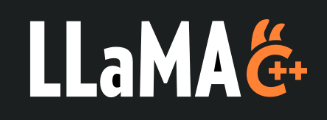

- llama.cpp는 C언어와 C++로 만들어진 **고성능 추론 Library**입니다!






- 반드시 써야하는 건 아닙니다!
  - 파인튜닝하고, 추론 테스트 할때는 PyTorch로 하면 충분합니다!
  - 연구할 때, 토이 프로젝트를 제작할때는 PyTorch, Transformers Library면 충분합니다!

- 하지만, **추론 서비스를 운영할때는 고성능 llama.cpp 라이브러리를 사용합니다,**
  - 허깅페이스의 Transformer로 추론하는 것보다 더 빠릅니다!
  - Unsloth로 추론하는 것 보다 더 빠릅니다!
  - 메모리를 더 적게 사용하고, 추론 속도가 빨라서 사용합니다!
    - AI 서비스를 운영할때는 추론속도가 빨라야 GPU 부담이 줄어듭니다.

### 모델 변환의 필요성 이해

- llama.cpp를 아주 간단히 소개드렸고, 이제 **왜 모델 변환이 필요한지 천천히 살펴봅시다.**

- 이전 수업에서 허깅페이스에 업로드된 모델을 다운로드 받아서 로드 했습니다.
  - .safetensors 라는 파일을 다운로드 받았었죠.
  - PyTorch가 사용하는 확장자입니다.

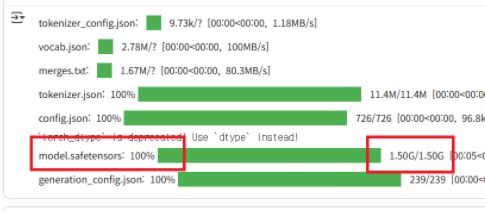

- 이렇게 다운로드 받고, 모델을 로드한 뒤 이런 일들을 해왔습니다.
  - 파인튜닝 or 추론을 해왔었죠.

- 파인튜닝으로 나만의 모델을 만들었습니다!
- 이제 세상 사람들이 내 모델을 사용할 수 있게끔, 챗봇 서비스를 만들 겁니다.

- 챗봇 서비스를 만들었는데, 답변 속도가 너무 느립니다.
  - 사용자들이 너무 느리다고 불만을 가집니다. ㅠㅠ
- GPU를 더 구매해도 되겠지만 너무 비싸요.
  - A100 GPU, 80GB 는 1,500만원이예요


- 방법을 찾았습니다!
  - 추론할때는 허깅페이스의 Transformer 라이브러리 대신 고성능 추론 Library를 사용하면 됩니다.
  - GPU를 추가 구매하지 않아도, 속도를 올릴 수 있습니다!

- 앗!!! llama.cpp 라이브러리는 PyTorch용 모델을 (.safetensor)를 지원하지 않습니다.
  - GGUF포맷 파일인 '.gguf' 파일로된 모델만 지원합니다. ㅠㅠ

- 그럼 내가 만든 모델을 llama.cpp 라이브러리에 쓸 수 있도록 GUFF로 변환해야합니다.

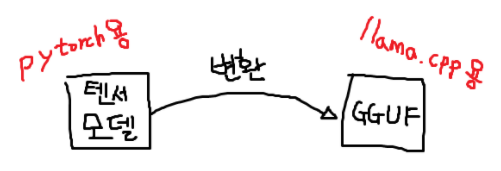

- 여기까지 모델을 변환해야하는 이유였습니다.

### GGUF에 대해서

- llama.cpp에서는 GGUF 포맷만을 지원합니다
  - 이 Library는 PyTorch 모델을 지원하지 않습니다.
  - 고성능 추론을 위해 GGUF 포맷의 모델로 변환을 할 수 밖에 없습니다.

- GGUF 라는 이름은 개발자의 이름을 따서 만들었습니다.
  - llama.cpp 라이브러리 개발자 이름은 Georgi Gerganov (조지 거가노브, 줄여서 GG) 입니다.
  - 그리고 GGUF의 약어는 Georgi Gerganov Unified Format 이죠.

- 이 GGUF 포맷을 따르는 파일은 .gguf 확장자를 갖습니다.
- 이 파일에는 다음과 같은 정보가 다~ 들어있습니다.
  - 텐서 파일 (Weight값)
  - Vocab
  - Model 메타정보
  - (양자화를 했다면, 양자화 정보)
  - 등등

- 이 파일 하나만 있으면 tokenizer, config 등 이런 파일들이 필요없어요.

### 허깅페이스에서 GGUF 구경하기

- 아래 사이트에 접속하여 Quantizations 버튼을 눌러봅시다.
  - https://huggingface.co/Qwen/Qwen3-0.6B
  - 아래 링크에서 양자화된 모델을 확인할 수 있습니다.

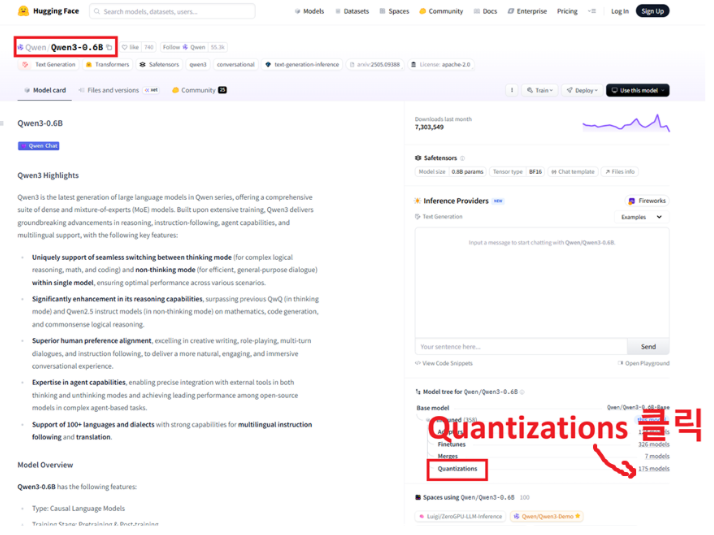

- 친숙한 unsloth가 보이네요.
  - unsloth의 GGUF 모델을 클릭해봅시다.

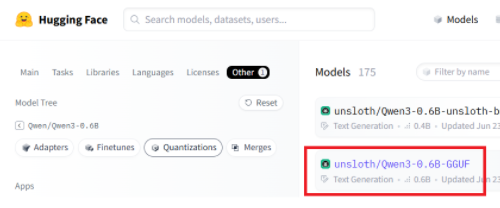

- 이후 Files 탭을 누르면 gguf 파일들을 확인할 수 있습니다.

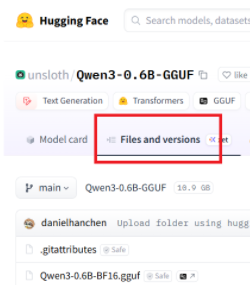

- PyTorch 모델은 .safetensors 파일로 되어있었지만,<br/>
  GGUF로 변환된 모델은 .gguf 파일로 되어있음을 확인할 수 있습니다.

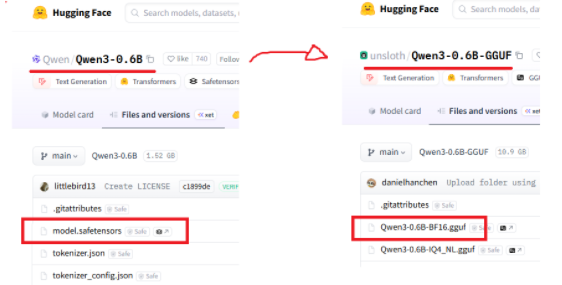

- 파일이 엄청 많습니다.

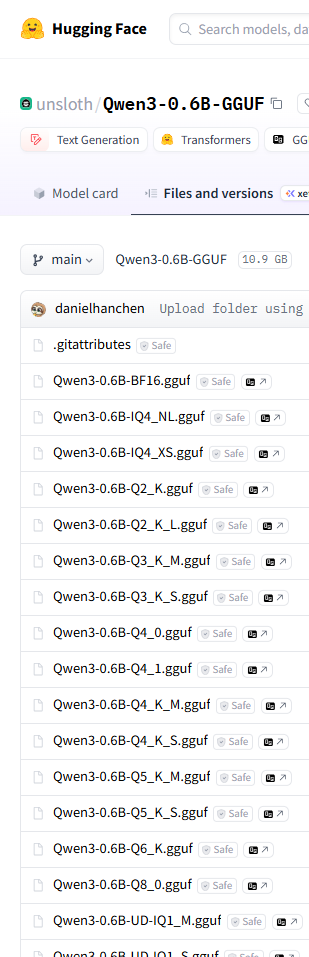


  - 이건 종류별로 하나씩 다 만든겁니다.
    - 아메리카노, 라떼, 프라페치노... 각각 동작되는 모델입니다.
    - **.gguf 파일 하나만 있으면 추론이 잘 됩니다.**
  - BF16 : 양자화 없는 원본
  - IQ : 더 정밀하고 손실이 적은 4bit 양자화
  - Q2, Q3, Q4, Q6.. = 양자화 bit 수
  - 그 뒤에 옵션은 양자화 세부 옵션들 (K_L, K_M, K_S)
- 이중에서 뭘 쓸까요?
  - llama.cpp 라이브러리가 가장 권장 권장하는 옵션은 **Q4_K_M** 입니다. 이걸 사용하면 됩니다.
  - https://github.com/ggml-org/llama.cpp
  - https://ai-sdk.dev/providers/community-providers/llama-cpp
  

# 2. GGUF 모델 성능 테스트
- GGUF 변환 후, 추론 속도가 정말 좋아지는지 확인해봅니다.


### GGUF 파일 추론 테스트
- llama.cpp 라이브러리를 사용하여 추론을 해봅시다.
- C++ Library의 Python 래퍼 가 있습니다.
  - C++ 코드를 직접 다루지 않아도 Python 코드처럼 쓸 수 있게 해주는 껍데기를 말합니다.
  - C++ 코드를 직접 쓰지 않아도 Python 코드로 C++ 내부 함수를 불러옵니다.
  - 이 Python 래퍼를 사용하기 위한 라이브러리가 **llama-cpp-python** 입니다.
    - 아래 설치 명령어는 GPU 옵션이 켜있는 패키지를 다운 받는 명령어입니다.
      - 단순히 llama-cpp-python을 설치하는 게 아니라, **CUDA 12.1 GPU 버전이 활성화된 패키지**를 설치하는 겁니다.
      - GPU 지원이 포함된 특별 빌드가 올라 있는 깃헙 저장소를 적습니다.
    - CUDA 12.1 버전은 CUDA 12.4 버전과 호환이 잘 됩니다.

In [1]:
%%capture
!pip install llama-cpp-python --extra-index-url https://abetlen.github.io/llama-cpp-python/whl/cu121
!pip install huggingface_hub

- 이후 GGUF 모델을 다운로드합니다.
- 허깅페이스에서 제공하는 다운로드 방식을 사용합니다.
  - /root/.cache/huggingface/hub/ 경로에 저장이 될꺼에요.


In [2]:
from huggingface_hub import hf_hub_download

model_path = hf_hub_download(
    repo_id="unsloth/Qwen3-0.6B-GGUF",
    filename="Qwen3-0.6B-BF16.gguf" # 양자화 안된 gguf
    #filename="Qwen3-0.6B-Q4_K_M.gguf" # 4bit 양자화 된 gguf
)
print("모델 다운로드 완료:", model_path)

Qwen3-0.6B-BF16.gguf:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

모델 다운로드 완료: /root/.cache/huggingface/hub/models--unsloth--Qwen3-0.6B-GGUF/snapshots/50968a4468ef4233ed78cd7c3de230dd1d61a56b/Qwen3-0.6B-BF16.gguf


  - 예전과 방식이 조금 다르죠?
  ```
  from transformers import AutoModelForCausalLM, AutoTokenizer

  model_name = "Qwen/Qwen3-0.6B"

  # load the tokenizer and the model
  tokenizer = AutoTokenizer.from_pretrained(model_name)
  model = AutoModelForCausalLM.from_pretrained(
      model_name,
      torch_dtype="auto",
      device_map="auto"
  )
  ```
그동안 썻던 이 방식은 허깅 페이스에서 trasformers라는 라이브러리를 이용해서 모델을 가져오는 것인데요, python코드 안에서 모델을 직접 쓸때 사용하는 방식이에요.
* 비교를 해보죠
| 구분            | `transformers` 방식      | `hf_hub_download` 방식            |
| ------------- | ---------------------- | ------------------------------- |
| **모델 포맷**     | `.bin`, `.safetensors` | `.gguf`                         |
| **목적**        | 학습/연구용 (PyTorch 모델)    | 추론/배포용 (llama.cpp 엔진)           |
| **불러오기 방식**   | Python 메모리에 직접 로드      | 단순 파일 다운로드                      |
| **실행 엔진**     | PyTorch                | llama.cpp (또는 llama-cpp-python) |
| **GPU 필요 여부** | 보통 필요함                 | 없어도 가능 (CPU 추론 가능)              |
| **양자화 지원**    | 없음(고정밀도 FP16/FP32)     | 지원(Q4, Q5, Q8 등)                |


- 모델을 로드합니다.

In [3]:
from llama_cpp import Llama

llm = Llama(
    model_path=model_path, # 다운로드한 GGUF 파일 경로
    n_gpu_layers=-1, # -1 : gpu에 모든 Layer 로드
    verbose=False, # 추론시 로그 출력 OFF
)


llama_context: n_ctx_seq (512) < n_ctx_train (40960) -- the full capacity of the model will not be utilized


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


경고 메시지는 무시합니다. 모델은 40K 토큰까지 기억할 수 있는데, 지금은 제한되어 있어서 성능을 다 못 쓸수도 있다는 경고인데 무시하셔도 좋습니다.

- 추론 시작!

In [5]:
import time, re

# 1. Qwen 모델 전용 프롬프트 템플릿 함수
# 모델이 시스템 설정과 사용자 질문을 구분할 수 있게 특수 토큰(<|im_start|>, <|im_end|>)을 삽입합니다.
def qwen_prompt(user_text, system_text):
    return f"<|im_start|>system\n{system_text}<|im_end|>\n<|im_start|>user\n{user_text}<|im_end|>\n<|im_start|>assistant\n"

user_text = "좋아하는 음식과 특징을 말해줘"
print(f"사람 : {user_text}")

system_text = "짧게 단답형으로 대답해"
# 설정된 텍스트들을 템플릿에 넣어 최종 프롬프트 생성
prompt = qwen_prompt(user_text, system_text)


# 2. LLM 추론 및 성능 측정 함수
def invoke():
    start = time.time() # 추론 시작 시간 기록
    # llm 객체(llama-cpp 등)를 통해 답변 생성. 최대 512토큰, 창의성(temp) 0.7 설정
    response = llm(prompt, max_tokens=512, temperature=0.7)
    elapsed = time.time() - start # 추론에 걸린 시간 계산

    # 3. 결과 전처리
    # DeepSeek나 Qwen3 하이브리드 같은 모델의 경우 생각 과정(<think>...</think>)이 포함될 수 있어 이를 제거하고 본문만 추출
    result = response["choices"][0]["text"].split("</think>")[-1].strip()

    print(f"AI : {result}")
    print(f"추론시간 : {elapsed:.2f}s")

    # 4. 토큰 수 계산 (간이 방식)
    # 공백을 제외한 글자 수를 토큰 수로 가정하여 계산 (실제 토큰과는 차이가 있을 수 있음)
    num_tokens = len(result.replace(" ", ""))
    return (elapsed, num_tokens)

# 5. 루프 및 누적 통계 계산
acc_elapsed = 0.0    # 누적 소요 시간
acc_tokens = 0       # 누적 생성 토큰 수
limit_tokens = 1000  # 목표 누적 토큰 제한선

while True:
    elapsed, num_tokens = invoke() # 1회 추론 실행 (소요시간, 토큰사용량)
    acc_elapsed = acc_elapsed + elapsed
    acc_tokens = acc_tokens + num_tokens

    print(f"누적 토큰 수: {acc_tokens} / {limit_tokens}")
    print()

    # 설정한 누적 토큰 수(1000개)를 넘어가면 반복 종료
    if acc_tokens > limit_tokens :
        break

# 6. 최종 성능 지표 계산
# TPS(Tokens Per Second): 초당 몇 개의 토큰을 생성했는지 나타내는 속도 지표
tps = acc_tokens / acc_elapsed

print(f"예상 토큰 수: {acc_tokens}")
print(f"초당 처리 속도: {tps:.2f} tokens/sec")

사람 : 좋아하는 음식과 특징을 말해줘
AI : 내가 좋아하는 음식은 고구마 치즈 카페인 카페소입니다. 특징은 풍부한 훌륭한 치즈와 신선한 야채 맛이 특이합니다.
추론시간 : 2.64s
누적 토큰 수: 49 / 1000

AI : 나는 훌륭한 음식과 특징을 알려줄 수 있습니다! 예를 들어, **피자**는 풍부한 아기요리로, 오븐에 끼워주며 발미래기 심장을 만들기 때문에 매우 맡겨요. **피자**의 특징은 풍부한 훌륭한 소고기, 양념, 그리고 맥박이 풍부합니다. 😊
추론시간 : 2.77s
누적 토큰 수: 152 / 1000

AI : 예, 좋아하는 음식은 피자입니다. 특징은 풍부한 토핑과 구운 레몬이상, 두꺼운 블랙오메가, 그리고 차분한 훌륭한 음식입니다. 🍕
추론시간 : 1.50s
누적 토큰 수: 208 / 1000

AI : 내가 좋아하는 음식은 떡볶이예요. 그는 훌륭한 왼쪽 구석, 달달한 고구마, 그리고 막힌 앨리비아 레드 레드와 함께 먹을 수 있어요!
추론시간 : 1.53s
누적 토큰 수: 263 / 1000

AI : 나는 주식이 좋아요. 주식은 풍부한 맛과 세련된 예술성을 특징으로합니다.
추론시간 : 1.48s
누적 토큰 수: 295 / 1000

AI : 망치하는 음식: 피자  
특징: 맛있고, 토마토와 채소가 섞어 풍부한 맛, 별도의 토마토와 채소가 추가되어 즐기는 음식입니다.
추론시간 : 1.65s
누적 토큰 수: 349 / 1000

AI : 내가 좋아하는 음식은 [예: 훈련용 음식]이며, 특징은 [특정 요소]로 이어집니다. (예시: "오리채"로 대체 가능)
추론시간 : 1.64s
누적 토큰 수: 401 / 1000

AI : 내가 좋아하는 음식은 **아스프랑디**입니다. 그 음식은 풍부한 양파와 토마토가 들어간 다양한 풍부한 맛과 풍부한 맛이 특징이죠.
추론시간 : 1.23s
누적 토큰 수: 458 / 1000

AI : 좋아하는 음식: **피자**  
특징: **양념이 많고, 풍부한 맛**.
추론시간 : 1.27s
누적 토큰 수: 490 /

### PyTorch 모델 추론 vs GGUF 모델 추론 속도 비교

- .gguf 모델은 배포용으로 사용된다고 배웠습니다.
  - C++ 기반 추론 Library인 llama.cpp 를 쓰기 위함입니다.

- 얼마나 성능차이가 나는지 확인해봅시다!
  - GGUF 성능이 더 빠른것을 확인할 수 있습니다.

In [6]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
model_name = "Qwen/Qwen3-0.6B"

# 모델 로드
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.bfloat16, #BF16
    device_map="auto"

)

config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [7]:
import time, re
user_text = "좋아하는 음식과 특징을 말해줘"
print(f"사람 : {user_text}")

system_text = "짧게 단답형으로 대답해"

messages = [
    {"role": "system", "content": system_text},
    {"role": "user", "content": user_text}
]

# Qwen 템플릿으로 변경
text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=False # Switches between thinking and non-thinking modes. Default is True.
)

# 토크나이저
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)


def invoke():
    start = time.time() # 시간측정 시작
    generated_ids = model.generate(**model_inputs, max_new_tokens=512)
    elapsed = time.time() - start # 시간측정 끝

    # 결과 저장
    output_ids = generated_ids[0][len(model_inputs.input_ids[0]):].tolist()
    result = tokenizer.decode(output_ids[0:], skip_special_tokens=True).strip("\n")

    print(f"AI : {result}")
    print(f"추론시간 : {elapsed:.2f}s")

    num_tokens = len(result.replace(" ", ""))
    return (elapsed, num_tokens)

acc_elapsed = 0.0
acc_tokens = 0
limit_tokens = 1000

while True:
  elapsed, num_tokens = invoke()
  acc_elapsed = acc_elapsed + elapsed
  acc_tokens = acc_tokens + num_tokens

  print(f"누적 토큰 수: {acc_tokens} / {limit_tokens}")
  print()

  # 생성된 예상 토큰수가 1000개 넘어가면 종료
  if acc_tokens > limit_tokens :
    break

tps = acc_tokens / acc_elapsed

print(f"예상 토큰 수: {acc_tokens}")
print(f"초당 처리 속도: {tps:.2f} tokens/sec")

사람 : 좋아하는 음식과 특징을 말해줘
AI : - **음식:** 쑤어
- **특징:** 풍부한 쌀, 풍부한 쌀, 쌀 뿌리, 쌀 풍부함, 쌀 뿌리, 쌀 풍부함, 쌀 뿌리, 쌀 풍부함, 쌀 뿌리, 쌀 풍부함, 쌀 뿌리, 쌀 풍부함, 쌀 뿌리, 쌀 풍부함, 쌀 뿌리, 쌀 풍부함, 쌀 뿌리, 쌀 풍부함, 쌀 뿌리, 쌀 풍부함, 쌀 뿌리, 쌀 풍부함, 쌀 뿌리, 쌀 풍부함, 쌀 뿌리, 쌀 풍부함, 쌀 뿌리, 쌀 풍부함, 쌀 뿌리, 쌀 풍부함, 쌀 뿌리, 쌀 풍부함, 쌀 뿌리, 쌀 풍부함, 쌀 뿌리, 쌀 풍부함, 쌀 뿌리, 쌀 풍부함, 쌀 뿌리, 쌀 풍부함, 쌀 뿌리, 쌀 풍부함, 쌀 뿌리, 쌀 풍부함, 쌀 뿌리, 쌀 풍부함, 쌀 뿌리, 쌀 풍부함, 쌀 뿌리, 쌀 풍부함, 쌀 뿌리, 쌀 풍부함, 쌀 뿌리, 쌀 풍부함, 쌀 뿌리, 쌀 풍부함, 쌀 뿌리, 쌀 풍부함, 쌀 뿌리, 쌀 풍부함, 쌀 뿌리, 쌀 풍부함, 쌀 뿌리, 쌀 풍부함, 쌀 뿌리, 쌀 풍부함, �
추론시간 : 27.88s
누적 토큰 수: 318 / 1000

AI : - ** 좋아하는 음식:** 콩치  
- **특징:** 맛있고, 맥박이 강한 소스로, 맛이 풍부합니다.
추론시간 : 2.08s
누적 토큰 수: 362 / 1000

AI : 좋은 음식은 풍부한 풍부한 곳입니다.
추론시간 : 1.05s
누적 토큰 수: 378 / 1000

AI : 아이스크림 🍕
추론시간 : 0.39s
누적 토큰 수: 384 / 1000

AI : 좋은 음식: 고소우, 특징: 맛있고 풍부합니다.
추론시간 : 1.16s
누적 토큰 수: 405 / 1000

AI : - **좋은 음식**: 주식이나 스타일링 요리  
- **특징**: 맛있고, 다양한 재료를 활용합니다.
추론시간 : 1.79s
누적 토큰 수: 450 / 1000

AI : 좋은 음식: 채식 식사 (예: 채식 채식, 채식 채식)  
특징: 빠르게 먹기, 맛있고, 건강하다.
추론시간 : 9.45s
누적 토큰 수: 491 / 1000

AI : 저는 케밥을 좋아하는 음식이며

### 실험 결과

- GGUF가 확실히 빠르게 토큰을 생성해냅니다.
- 추론 안정성도 차이가 있었습니다.
  - GGUF는 한번에 결과가 잘 나오는데, PyTorch는 4번중 1번 실행시 무한루프에 빠지곤 했습니다.
- 당연하게도 4bit 양자화 한 모델이 그렇지 않은 모델보다 많이 빠릅니다.
  - 생성된 문장의 품질은 비교하지 못했습니다.
  - 이는 LLM as a judge 를 통해 평가할 수 있습니다.
- GGUF 포멧으로 바꾼 모델이 Pytorch 기반 모델보다 빨랐습니다.
  - 이는 파라미터가 C/C++에서 바로 읽을 수 있는 구조라서 그렇습니다.
    - PyTorch: Python → CUDA드라이버 → GPU 메모리 복사 → 연산
    - llama.cpp: C++ → 메모리 직접 접근 (겁나빠름)
- 역시 배포는 GGUF로 해야되겠습니다.

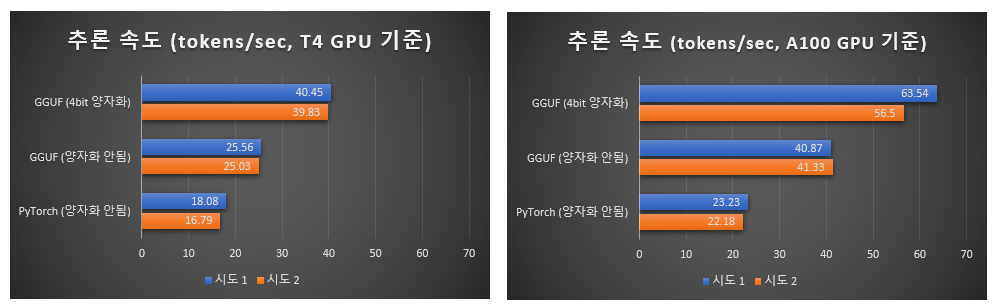

# 3. GUFF 모델 변환하기


### 변환할 모델 준비

- 이번 챕터에서는 PyTorch 모델을 직접 GGUF로 변환 후 추론까지 해보겠습니다.
- 먼저 모델을 로드 후, 파일로 저장하겠습니다.

In [8]:
# 모델 저장
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "Qwen/Qwen3-0.6B"

# 모델 다운로드 & 로드
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)


# 이후 파인튜닝을 다 했다고 가정합니다.
# 파인튜닝 코드 시작
# ...~
# 파인튜닝 코드 끝


# 파인튜닝 완료된 모델 저장 (5분 소요)
print('모델 저장중...')
save_path = "./my_trained_model"
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print("모델 저장 완료:", save_path)


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


모델 저장중...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

모델 저장 완료: ./my_trained_model


- 저장이 잘 된것을 확인할 수 있습니다.

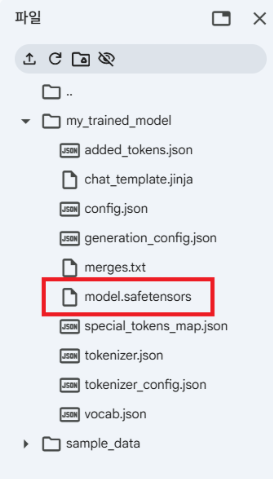

### GGUF 포맷으로 변환

- 이제 .safetensors --> GGUF로 변환을 해야하는데 두 가지 방법이 있습니다.

- 방법1 : llama.cpp 공식 가이드
  1. `git clone https://github.com/ggerganov/llama.cpp` 으로 Clone 받고
  2. convert_hf_to_gguf.py로 GGUF 변환 (BF16)을 하고
  3. 빌드하고 (cmake)
  4. llama-quantize 툴로 4bit 양자화를 한다.

<br/>

- **방법2 : Unsloth 함수 호출**
  1. save_pretrained_gguf() 함수를 호출한다.
      - 내부적으로 위 동작을 수행합니다.
  2. 끝!

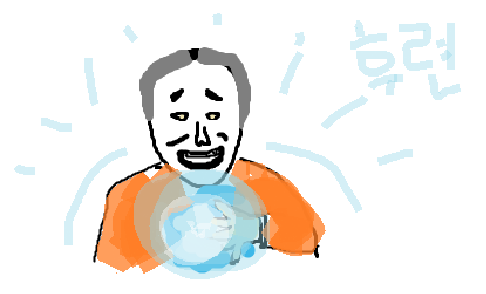

- unsloth 를 설치합시다.

In [9]:
!pip install unsloth

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.9/62.9 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.8/403.8 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 89.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 97.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.7/183.7 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.9

- [Trouble Shooting] 아래는 버전 충돌로 인한 해결책입니다.

In [2]:
!pip uninstall -y pyarrow
!pip install pyarrow==17.0.0

  Using cached pyarrow-17.0.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (3.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.9/39.9 MB 14.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.3.0 requires pyarrow>=21.0.0, but you have pyarrow 17.0.0 which is incompatible.


- 변환합니다!
  - 아래 코드를 실행하면, 16분 정도 걸린다고 로그 메세지가 나옵니다.

In [3]:
from unsloth import FastLanguageModel

# 기존 저장된 모델 경로
model_path = "./my_trained_model"

# GGUF 변환 (오래걸림)
model, tokenizer = FastLanguageModel.from_pretrained(model_path, dtype = None)

# 양자화 후 저장
model.save_pretrained_gguf(
    model_path,
    tokenizer = tokenizer,
    quantization_method = "q4_k_m",
)

print('변환 완료!')

/tmp/ipykernel_16456/1495885337.py:1: UserWarning: WARNING: Unsloth should be imported before [transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastLanguageModel


🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.3.18: Fast Qwen3 patching. Transformers: 5.3.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Unsloth: Model is not a PEFT model. Using existing checkpoint at ./my_trained_model
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: Updating system package directories
Unsloth: Cloning llama.cpp repository...
Unsloth: Building llama.cpp - please wait 1 to 3 minutes
Unsloth: Successfully installed llama.cpp!
Unsloth: Preparing converter script...


Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['./my_trained_model_gguf/my_trained_model.F16.gguf']
Unsloth: [2] Converting GGUF f16 into q4_k_m. This might take 10 minutes...
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['./my_trained_model_gguf/my_trained_model.Q4_K_M.gguf']
Unsloth: No Ollama template mapping found for model './my_trained_model'. Skipping Ollama Modelfile
Unsloth: example usage for text only LLMs: /root/.unsloth/llama.cpp/llama-cli --model ./my_trained_model_gguf/my_trained_model.Q4_K_M.gguf -p "why is the sky blue?"
변환 완료!


- 아래 파일이 생성 되었으면 성공입니다.

image.png

### 생성한 .gguf파일 추론 테스트

In [4]:

%%capture
!pip install llama-cpp-python --extra-index-url https://abetlen.github.io/llama-cpp-python/whl/cu121

- 생성된 파일을 추론테스트 해봅니다.

In [5]:
from llama_cpp import Llama

# 로컬 파일을 불러옵니다.
model_path = "./my_trained_model_gguf/my_trained_model.Q4_K_M.gguf"

llm = Llama(
    model_path=model_path, # 다운로드한 GGUF 파일 경로
    n_gpu_layers=-1, # -1 : gpu에 모든 Layer 로드
    verbose=False, # 추론시 로그 출력 OFF
)

llama_context: n_ctx_seq (512) < n_ctx_train (40960) -- the full capacity of the model will not be utilized


In [6]:
def qwen_prompt(user_text, system_text):
    return f"<|im_start|>system\n{system_text}<|im_end|>\n<|im_start|>user\n{user_text}<|im_end|>\n<|im_start|>assistant\n"

user_text = "좋아하는 음식과 특징을 말해줘"
print(f"사람 : {user_text}")

system_text = "짧게 단답형으로 대답해"
prompt = qwen_prompt(user_text, system_text)

response = llm(prompt, max_tokens=512, temperature=0.7)

# 결과 저장
result = response["choices"][0]["text"].split("</think>")[-1].strip()

print(f"AI : {result}")

사람 : 좋아하는 음식과 특징을 말해줘
AI : 좋은 음식과 특징은 "치킨"입니다. 예를 들어 훌프치킨은 풍부한 양념과 훌루드 햄스름한 향이 특징이죠. 😊


- 여기까지 모델 변환을 해보았습니다.
  - 이제 LLM 모델을 파인튜닝을 하신 후, GGUF로 변환 후 추론까지 가능해졌습니다.

# 4. Benchmark Tool로 성능 테스트

### 벤치마크 도구 준비

- 3번 실습에서 unsloth로 GGUF를 수행하면 llama.cpp가 Clone & Build가 됩니다.
- llama.cpp 폴더 안에는 추론 속도를 테스트 할 수 있는 도구가 포함되어있습니다.

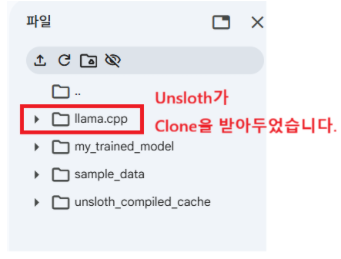

- 벤치마크 툴을 실행을 위해 빌드합니다.
  - 10분 걸립니다.
    - 멈춰있는 것 같지만, 빌드 중입니다.

* 현재 작업 디렉터리를 llama.cpp 폴더로 이동후

* cmake 를 통해서 빌드를 설정합니다.
  - cmake 는 C/C++ 프로젝트의 “자동 설치·빌드 시스템 입니다.
  - 결과를 build 폴더에, cuda기능을 켜서 컴파일하고, llama.cpp안에 있는 보조 도구들 모두 함께 빌드할 준비 설정을 먼저 합니다.

In [7]:
%cd llama.cpp
!cmake -B build -DGGML_CUDA=on -DLLAMA_BUILD_TOOLS=ON

[Errno 2] No such file or directory: 'llama.cpp'
/content
CMake Error: The source directory "/content" does not appear to contain CMakeLists.txt.
Specify --help for usage, or press the help button on the CMake GUI.


CMake에게 명령을 내려요. 이제 빌드를 실행해라. 그런데 아까 build 폴더에 생성된 설정(빌드 계획)에 따라 진행하고, 여러 실행 파일 중에서 벤치마크용 실행 파일(llama-bench)만 컴파일 및 링크하라는 뜻입니다.
 - -j 옵션은 병렬 컴파일의 약자 입니다. 이 옵션을 쓰면 cmake가 자동으로 최적의 코어수를 감지해서 사용합니다.

In [8]:
!cmake --build build --target llama-bench -j

Error: /content/build is not a directory


### 벤치마크 수행

- 벤치마크 툴을 실행해봅니다.
  - pp512
    - 한번에 512개 토큰 단위로 모델에 입력합니다
    - 이때, 1초에 **입력(인코딩)** 처리 할수 있는 있는 토큰 수를 나타냅니다.
  - tg128
    - 한번에 128개 토큰 단위로 생성합니다.
    - 이때, 1초에 **생성(디코딩)** 할 수 있는 토큰 수를 나타냅니다.

In [9]:
%cd /content/
!./llama.cpp/build/bin/llama-bench -m ./my_trained_model.Q4_K_M.gguf -p 512 -n 128

/content
/bin/bash: line 1: ./llama.cpp/build/bin/llama-bench: No such file or directory


### 벤치마크 결과 분석

- 만약 출력결과가 아래와 같으면, 이렇게 해석합니다.
  - 인코딩 속도 : 초당 16,369개 토큰
  - 디코딩 속도 : 초당 343개 토큰

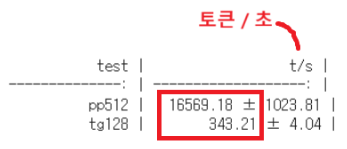

- 이번엔 모델을 더 추가해서 모델별 성능비교를 해봅시다.

In [ ]:
from huggingface_hub import hf_hub_download

model_path = hf_hub_download(
    repo_id="unsloth/Qwen3-0.6B-GGUF",
    filename="Qwen3-0.6B-BF16.gguf", # 양자화 안된 gguf
    local_dir="./"
)

print("모델 다운로드 완료")

- 다운로드 받은 모델 성능을 측정하고, 비교해봅시다.
  - 이번엔 양자화가 안된 모델이므로, 성능이 더 낮을 것입니다.

In [ ]:
%cd /content/
!./llama.cpp/build/bin/llama-bench -m ./Qwen3-0.6B-BF16.gguf -p 512 -n 128

- 이렇게 양자화를 함으로써, 정확한 데이터로 추론 속도를 비교할 수 있었습니다.

- 모델별 성능 비교도 가능하지만, HW 성능 측정도 가능합니다.
  - 한 모델을 기준으로, 여러 장치들을 바꿔가면서 성능측정 할 수 있습니다.
  - 아래 링크를 보시면, Llama 2 7B 기준의 Score 보드입니다.
    - https://github.com/ggml-org/llama.cpp/discussions/15013
      - RTX 5090 GPU가 A100 GPU보다 경량모델의 추론속도가 빠르군요!


- 여기까지 모델의 추론 속도를 정확히 측정하는 방법을 학습했습니다.

# 5. GGUF 포맷의 한계점

### GGUF 포맷의 한계점

- GGUF은 추론 전용 포맷입니다!
  - GGUF로 변환된 모델은 LoRA 등 파인튜닝이 되지 않습니다.
- GGUF는 Transformer 계열 LLM 전용입니다!
  - CNN 기반 모델 사용 불가능합니다.
  - 멀티모달 LLM은 제한적으로 사용 가능합니다.
  - ViT와 같은 이미지 Transformer 모델도 제한적입니다.

<br/>

- GGUF로 양자화가 안되는 모델의 대안은 무엇이 있을까요!?
  - 바로 **TFLite** 입니다.
    - TensorFlow의 Lite 버전 입니다.
    - Google이 만든 경량화된 모델을 위한 프레임워크입니다.
      - PyTorch로 안되니, Tensorflow로 해야죠 ㅎㅎ

### TFLite 의 활용처
  - 임베디드 환경에서 가장 많이 쓰입니다.
    - 임베디드 장치는 tflite만 지원하는 경우가 많습니다.
  - 모바일 환경에서도 쓰입니다.    
    - TensorFlow Lite SDK 를 활용한 iOS / Android App을 만들 수 있습니다.
  - 서버 환경에서도 쓰입니다.
    - llama.cpp를 사용하지 못하는 모델에 사용됩니다.
    - CNN 기반 모델, 멀티모달 Transformer 등 지원합니다.
    - 정확히 사용하고자 하는 모델별로 지원 여부를 확인 후 사용해야합니다!
  - EASY 교안에서는 TFLite를 다루지 않습니다~.

# 6. 모델 배포

### 모델을 허깅페이스의 Repository에 Push하기


- 지금까지 양자화를 하여 배포할 준비를 끝냈으니, 이번 챕터에서는 모델을 배포해보겠습니다.
- 허깅페이스에 접속하여 Model Repository를 생성해주세요.

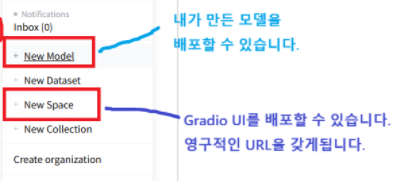

- Public으로 생성합니다.
  - 모델이름은 자유롭게 정합니다.

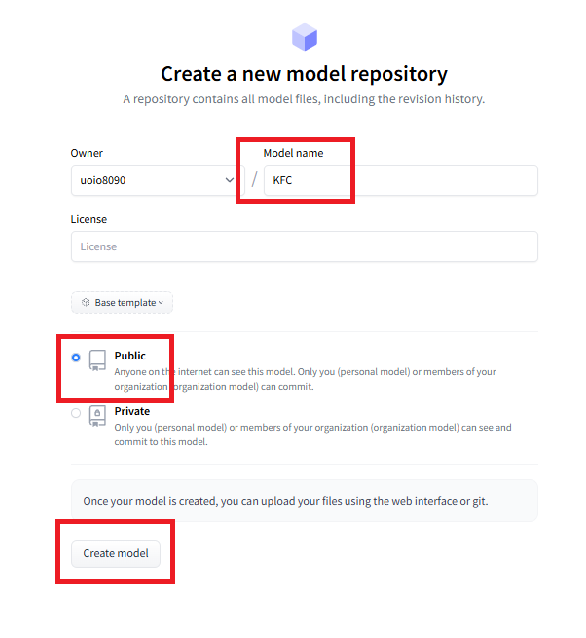

- Model Card에 Push 하는 명령어가 나와있습니다.

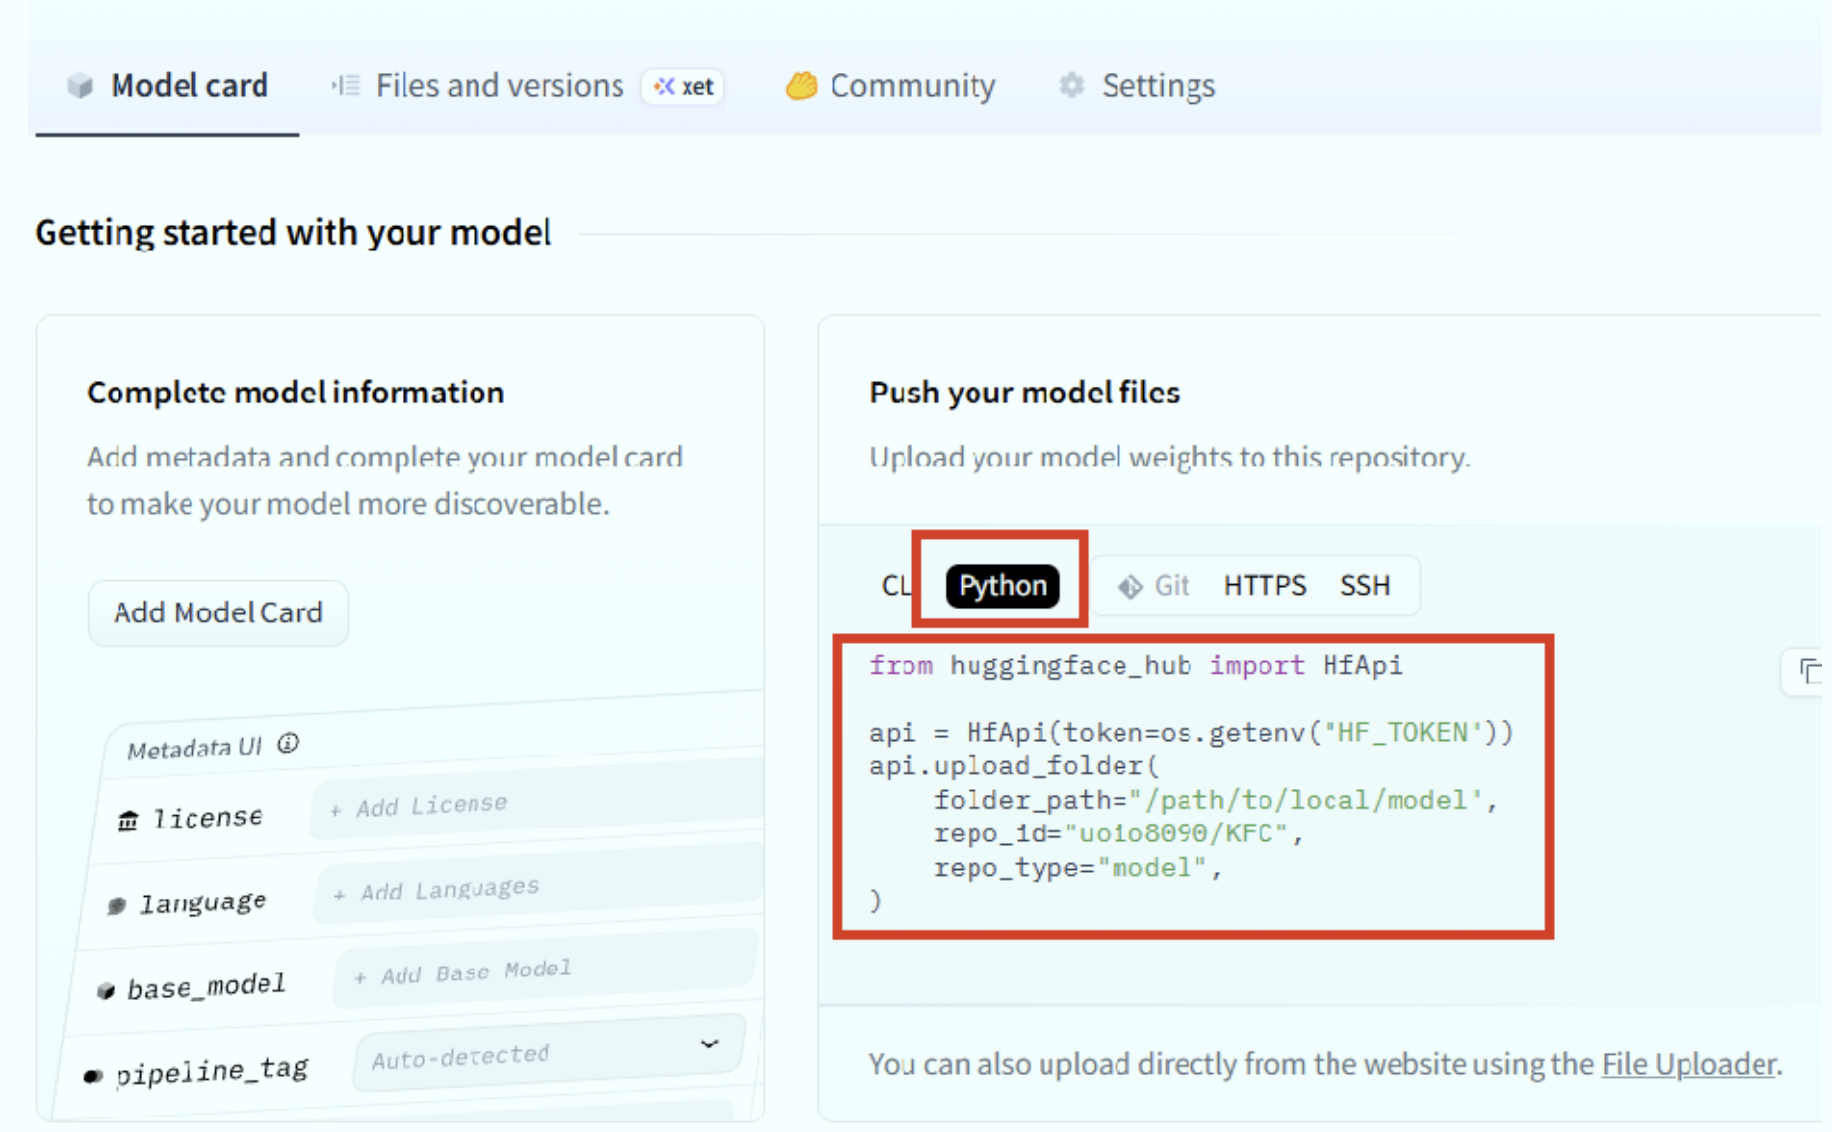

- 허깅페이스 키가 필요합니다. Write 권한으로 생성 해주세요.

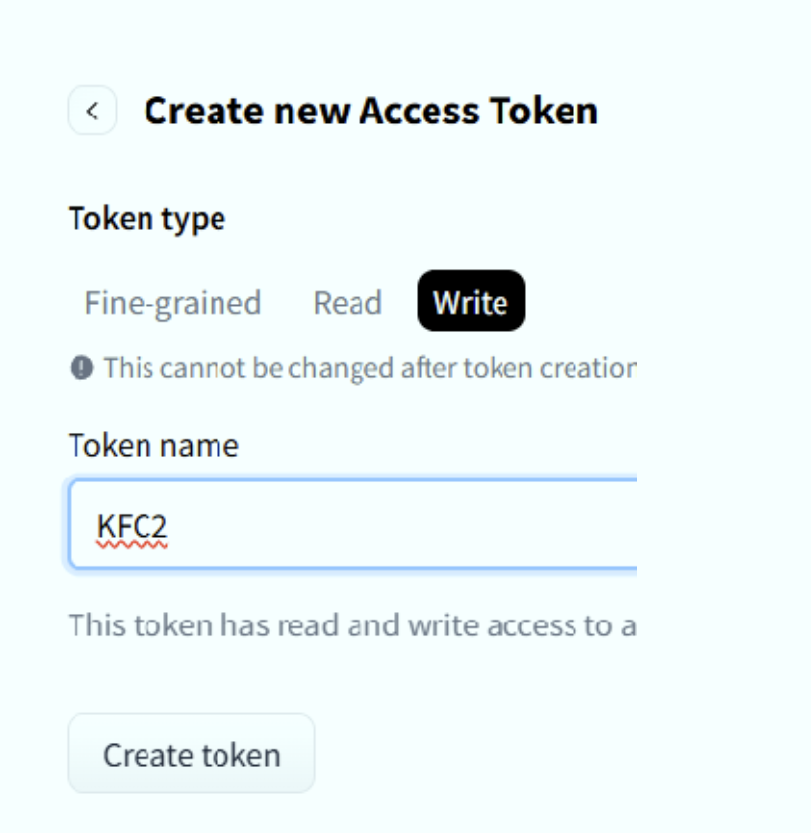

- 아래와 같이 등록해두었습니다.

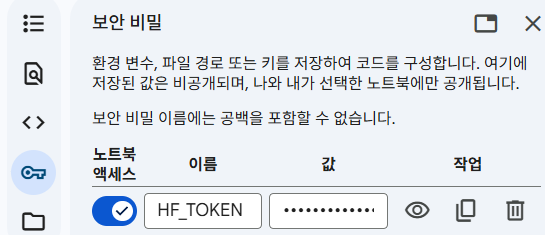

- 아래 코드를 수정하여 Push를 합시다.
  - 본인의 Repository로 수정하여 Push 합니다.

In [ ]:
from huggingface_hub import HfApi
import os

from google.colab import userdata
api = HfApi(token=userdata.get('HF_TOKEN'))

api.upload_file(
    path_or_fileobj="./my_trained_model_gguf/my_trained_model.Q4_K_M.gguf",  # 로컬 파일 경로
    path_in_repo="my_trained_model.Q4_K_M.gguf",       # HF Hub에서 보일 파일 이름
    repo_id="sfminho/KFC",                            # 본인 Repo (예: username/repo)
    repo_type="model",                                 # 모델 repo
)

- Push가 완료 되었습니다.

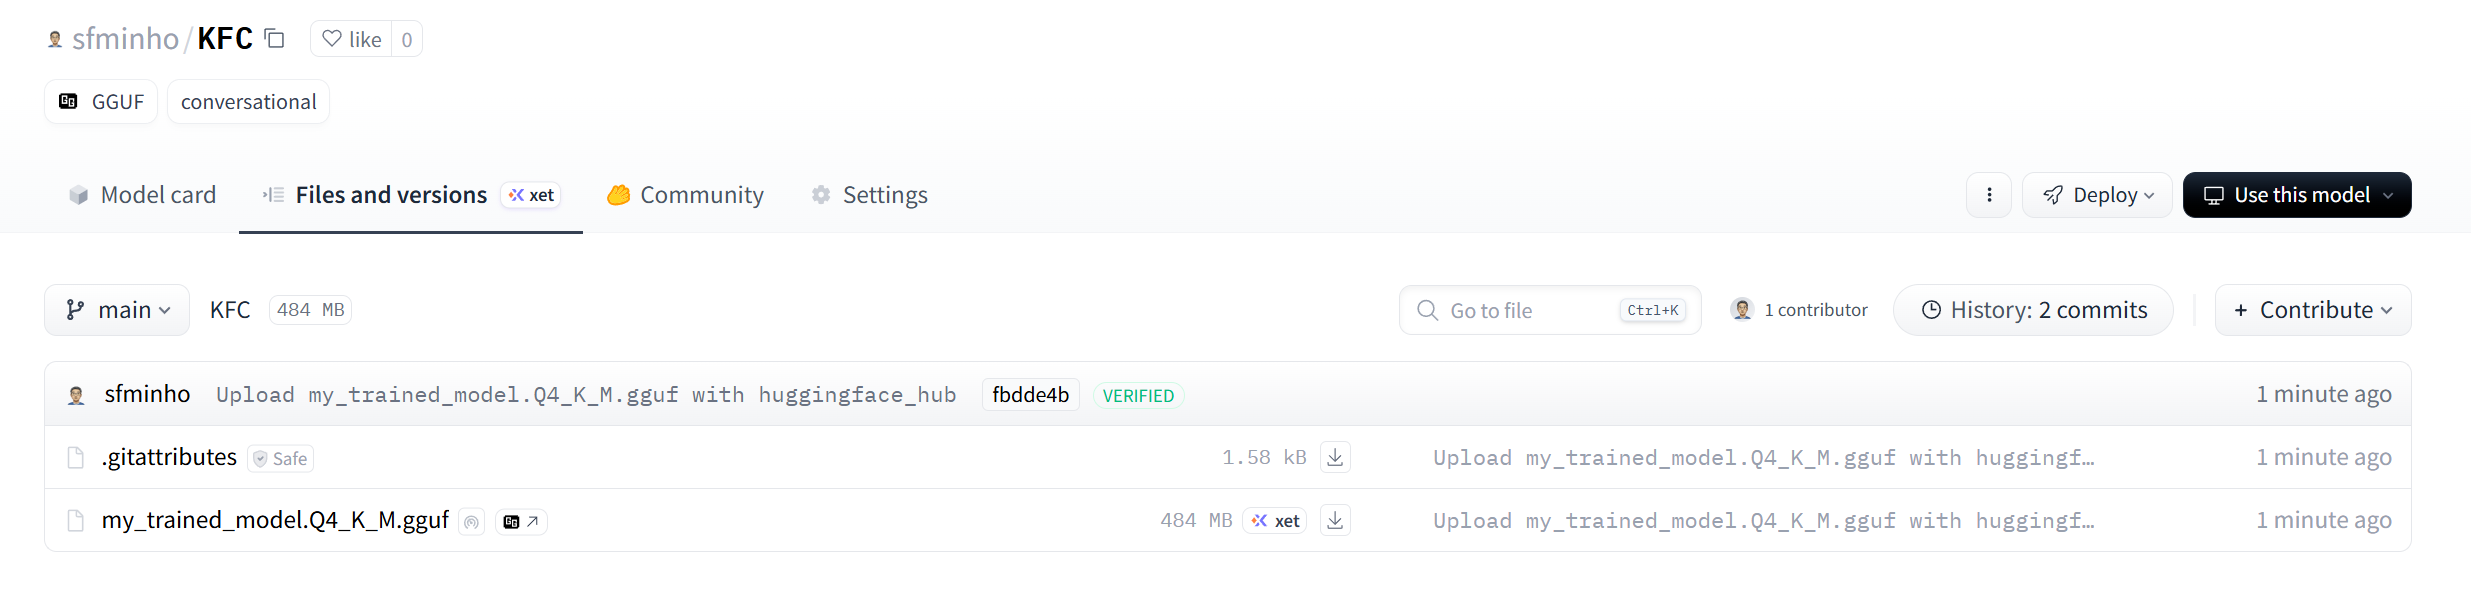

- 다음 실습을 위해 Model Repository 이름을 메모해주세요.

### Push한 모델 동작 테스트

- 아래 코드가 잘되는지 확인합니다.
  - 본인의 Repo 명과 GGUF 파일명으로 바꿔주세요


In [ ]:
import gradio as gr
from huggingface_hub import hf_hub_download
from llama_cpp import Llama

# ========================================
# 모델 다운로드
# ========================================
REPO_ID = "sfminho/KFC"              # Hugging Face Repo
MODEL_FILE = "my_trained_model.Q4_K_M.gguf"  # GGUF 파일명

model_path = hf_hub_download(repo_id=REPO_ID, filename=MODEL_FILE)

# ========================================
# 모델 로드
# ========================================
llm = Llama(
    model_path=model_path, # 다운로드한 GGUF 파일 경로
    n_gpu_layers=-1, # -1 : gpu에 모든 Layer 로드
    verbose=False, # 추론시 로그 출력 OFF
)

# ========================================
# 추론 함수 정의
# ========================================
def qwen_prompt(user_text, system_text):
    return f"<|im_start|>system\n{system_text}<|im_end|>\n<|im_start|>user\n{user_text}<|im_end|>\n<|im_start|>assistant\n"

def invoke(prompt):
    response = llm(prompt, max_tokens=512, temperature=0.7)
    result = response["choices"][0]["text"].split("</think>")[-1].strip()
    return result

def chat(message, history):
    system_text = "친절하게 대답해"
    prompt = qwen_prompt(message, system_text)
    answer = invoke(prompt)

    history = history + [
        {"role": "user", "content": message},
        {"role": "assistant", "content": answer}
    ]
    return "", history

# ========================================
# Gradio Blocks 기반 UI
# ========================================
with gr.Blocks(title="LangChain Agent Chat") as demo:
    gr.Markdown("## 🤖 LangChain Agent Chat\nLangChain Agent가 도구를 활용해 답변합니다.")

    chatbot = gr.Chatbot(
        height=300,
        label="대화창",
        type="messages"
    )

    msg = gr.Textbox(
        label="💬 질문을 입력하세요",
        placeholder="예: 오늘 서울 날씨 어때?",
    )

    # 엔터 누르면 chat 함수 호출
    msg.submit(chat, inputs=[msg, chatbot], outputs=[msg, chatbot])

demo.launch(share=True)

# 7. 미션

다음 미션을 도전해 보세요
  1. Qwen3-0.6B 모델을 파인튜닝 (제주도 사투리 파인튜닝)
  2. 4 bit 양자화 (GGUF)
  3. 허깅페이스에 모델 Push하기
  